##**SARIMAX (The Baseline)**

### **Concept**
**SARIMAX** (Seasonal AutoRegressive Integrated Moving Average with eXogenous factors) serves as our statistical baseline. It predicts future storage by analyzing:
1.  **Past Values (AR):** The "memory" of the reservoir.
2.  **Past Errors (MA):** Correcting previous prediction mistakes.
3.  **External Factors (X):** Using **Rainfall** and **Inflow** as leading indicators.



### **Configuration**
* **Order $(1, 0, 1)$:** We use 1 auto-regressive lag, 0 differencing (since data is stationary), and 1 moving average lag.
* **Exogenous Vars:** `Rainfall`, `Inflow`, and `Rainfall_Lag1`.

**Import Required libraries and Modules**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import sys
import os

**Setup & Data Loading**

In [2]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/EDI-III Project/Data/Processed Data'
else:
    BASE_PATH = '.'

file_path = os.path.join(BASE_PATH, 'Chembarambakkam.csv')
print(f"Loading data from: {file_path}")

try:
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    if df.index.duplicated().any():
        print(f"Warning: Found {df.index.duplicated().sum()} duplicate dates. Keeping the first occurrence.")
        df = df[~df.index.duplicated(keep='first')]

    df = df.asfreq('D')

    df = df.ffill()
except FileNotFoundError:
    print("Error: File not found. Please run the Data Processing script first.")
    sys.exit()

Mounted at /content/drive
Loading data from: /content/drive/MyDrive/EDI-III Project/Data/Processed Data/Chembarambakkam.csv


**Train & Test Data splitting**

In [3]:
test_days = 730
train = df.iloc[:-test_days]
test = df.iloc[-test_days:]

print(f"Training Data: {train.shape[0]} days")
print(f"Testing Data: {test.shape[0]} days")

# Define Target (y) and Exogenous Features (X)
target_col = 'Storage (mcft)'
exog_cols = ['Rainfall (mm)', 'Inflow (cusecs)', 'Rainfall_Lag1', 'Inflow_Lag1']

y_train = train[target_col]
X_train = train[exog_cols]

y_test = test[target_col]
X_test = test[exog_cols]

Training Data: 6812 days
Testing Data: 730 days


**Build & Fit SARIMAX Model**

In [4]:
print("\nFitting SARIMAX Model (1, 0, 1)...")

# We assume exogenous vars handle the seasonality to keep the base model lightweight.
model = SARIMAX(y_train, exog=X_train, order=(1, 0, 1), enforce_stationarity=False, enforce_invertibility=False)
model_fit = model.fit(disp=False)

print(model_fit.summary())


Fitting SARIMAX Model (1, 0, 1)...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:         Storage (mcft)   No. Observations:                 6812
Model:               SARIMAX(1, 0, 1)   Log Likelihood              -46494.275
Date:                Thu, 01 Jan 2026   AIC                          93002.550
Time:                        14:12:04   BIC                          93050.333
Sample:                    01-07-2004   HQIC                         93019.038
                         - 08-31-2022                                         
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Rainfall (mm)      -0.2274      0.366     -0.621      0.535      -0.946       0.491
Inflow (cusecs)     0.0559      0.008      7.212      0.000       0.041       0.071
Rainfall_Lag1      -5.8061      

**Forecasting**

In [5]:
print("\nGenerating Forecast...")

# We must provide the exogenous variables (X_test) for the future dates
forecast = model_fit.get_forecast(steps=len(test), exog=X_test)
forecast_values = forecast.predicted_mean
conf_int = forecast.conf_int()


Generating Forecast...


**Evaluation Metrics**

In [6]:
# Calculate RMSE and MAE
rmse = np.sqrt(mean_squared_error(y_test, forecast_values))
mae = mean_absolute_error(y_test, forecast_values)

# Calculate MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test - forecast_values) / (y_test + 1e-10))) * 100

# Calculate R^2 Score (Coefficient of Determination)
r2 = r2_score(y_test, forecast_values)

print(f"\n{'='*30}")
print(f"SARIMAX MODEL EVALUATION")
print(f"{'='*30}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} mcft")
print(f"MAE  (Mean Absolute Error):     {mae:.2f} mcft")
print(f"MAPE (Mean Abs. % Error):       {mape:.2f} %")
print(f"R^2  (Coefficient of Det.):     {r2:.4f}")
print(f"{'='*30}")


SARIMAX MODEL EVALUATION
RMSE (Root Mean Squared Error): 1083.13 mcft
MAE  (Mean Absolute Error):     884.65 mcft
MAPE (Mean Abs. % Error):       41.68 %
R^2  (Coefficient of Det.):     -2.8545


**Optimization of Model**

In [7]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.0 MB/s eta 0:00:00


In [8]:
import pmdarima as pm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

print("Running Auto-ARIMA to find optimal parameters...")
print("(This may take a few minutes)...")

# auto_arima will try different (p,d,q) and return the best model
model_auto = pm.auto_arima(
    y_train,
    exogenous=X_train,
    start_p=0, start_q=0,
    max_p=3, max_q=3, # Limit range to keep it fast
    d=None,           # Let model determine 'd' (differencing)
    seasonal=False,   # Keep False for speed, True is very slow on daily data
    trace=True,       # Print progress
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("\nBest Model Found:")
print(model_auto.summary())

Running Auto-ARIMA to find optimal parameters...
(This may take a few minutes)...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=83257.473, Time=0.24 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=82156.216, Time=0.32 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=81972.124, Time=1.66 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=83255.606, Time=0.11 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=81968.962, Time=2.26 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=81970.982, Time=2.34 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=81971.023, Time=3.29 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=81968.801, Time=4.85 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=81970.177, Time=3.61 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=81879.308, Time=13.31 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=81879.196, Time=18.32 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=81878.712, Time=12.62 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=81871.440, Time=12.84 sec


**Forecasting for Optimized Model**

In [9]:
print("\nGenerating Forecast with Optimized Model...")
# Predict on Test Set
forecast_optimized = model_auto.predict(n_periods=len(test), X=X_test)


Generating Forecast with Optimized Model...


**Evaluation for Optimized Model**

In [10]:
#Evaluation
rmse_opt = np.sqrt(mean_squared_error(y_test, forecast_optimized))
mae_opt = mean_absolute_error(y_test, forecast_optimized)
r2_opt = r2_score(y_test, forecast_optimized)

print(f"\n{'='*30}")
print(f"OPTIMIZED SARIMAX RESULTS")
print(f"{'='*30}")
print(f"RMSE : {rmse_opt:.2f} mcft")
print(f"MAE  : {mae_opt:.2f} mcft")
print(f"R²   : {r2_opt:.4f}")
print(f"{'='*30}")


OPTIMIZED SARIMAX RESULTS
RMSE : 975.48 mcft
MAE  : 802.36 mcft
R²   : -2.1264


**Visualization**

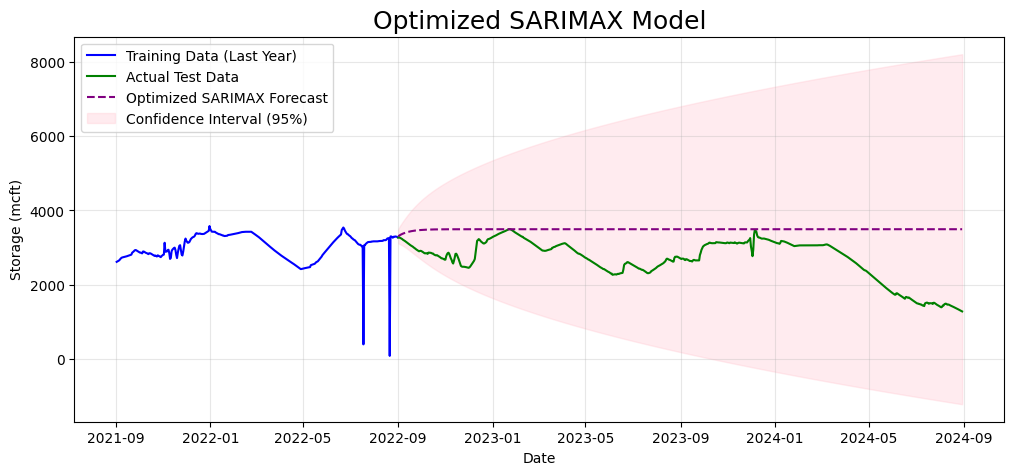

In [11]:
import matplotlib.pyplot as plt

forecast_optimized, conf_int_opt = model_auto.predict(
    n_periods=len(test),
    X=X_test,
    return_conf_int=True
)

# Plotting
plt.figure(figsize=(12, 5))

# Plot only the last 3 years for context
plot_start_date = train.index[-365]
subset_train = train[train.index > plot_start_date]

# 1. Training Data (Last Year)
plt.plot(subset_train.index, subset_train[target_col], label='Training Data (Last Year)', color='blue')

# 2. Actual Test Data
plt.plot(test.index, y_test, label='Actual Test Data', color='green')

# 3. Optimized Forecast
plt.plot(test.index, forecast_optimized, label='Optimized SARIMAX Forecast', color='purple', linestyle='--')

# 4. Confidence Intervals (The Pink Area)
plt.fill_between(
    test.index,
    conf_int_opt[:, 0], # Lower Bound
    conf_int_opt[:, 1], # Upper Bound
    color='pink',
    alpha=0.3,
    label='Confidence Interval (95%)'
)

plt.title('Optimized SARIMAX Model', fontsize=18)
plt.xlabel('Date')
plt.ylabel('Storage (mcft)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

**Residual Analysis**

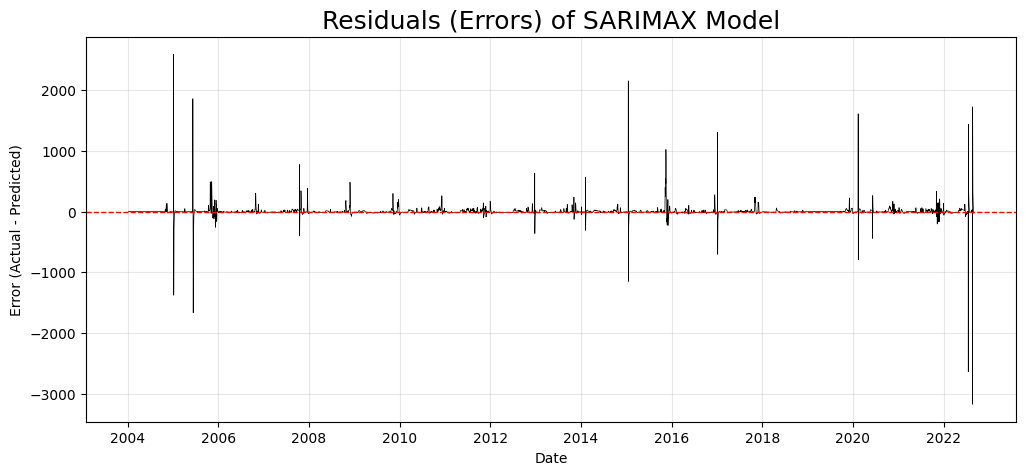

In [12]:
# Plot Residuals
residuals_opt = model_auto.resid()

plt.figure(figsize=(12, 5))

plt.plot(train.index, residuals_opt, color='black', linewidth=0.5)

plt.title('Residuals (Errors) of SARIMAX Model', fontsize=18)
plt.ylabel('Error (Actual - Predicted)')
plt.xlabel('Date')
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Zero line for reference
plt.grid(True, alpha=0.3)
plt.show()